In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from pygam import LinearGAM, s, te

# transformer package (pytorch)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
# importing and browsing data
csv_path = Path("..") / "Dataset" / "Outputs" / "CS2_model_input.csv"
df = pd.read_csv(csv_path)

print("Path:", csv_path.resolve())
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
display(df.head(5))

Path: D:\Model\Data-Science-Case-Study-1\Dataset\Outputs\CS2_model_input.csv
Shape: (70128, 24)

Columns: ['Zone', 'PM25', 'Datetime_UTC', 'fire_count_regional', 'frp_regional_sum', 'hfi_weighted', 'fwi_mean', 'fire_count_local', 'frp_local_sum', 'PM25_lag_1h', 'PM25_lag_6h', 'PM25_lag_24h', 'PM25_lag_48h', 'PM25_roll_24h_mean', 'PM25_roll_24h_max', 'PM25_roll_7d_mean', 'frp_roll_24h_sum', 'frp_roll_72h_sum', 'hour', 'day_of_week', 'month', 'is_wildfire_season', 'season', 'alert']

Dtypes:
 Zone                       str
PM25                   float64
Datetime_UTC               str
fire_count_regional    float64
frp_regional_sum       float64
hfi_weighted           float64
fwi_mean               float64
fire_count_local       float64
frp_local_sum          float64
PM25_lag_1h            float64
PM25_lag_6h            float64
PM25_lag_24h           float64
PM25_lag_48h           float64
PM25_roll_24h_mean     float64
PM25_roll_24h_max      float64
PM25_roll_7d_mean      float64
frp_roll

,Zone,PM25,Datetime_UTC,fire_count_regional,frp_regional_sum,hfi_weighted,fwi_mean,fire_count_local,frp_local_sum,PM25_lag_1h,...,PM25_roll_24h_max,PM25_roll_7d_mean,frp_roll_24h_sum,frp_roll_72h_sum,hour,day_of_week,month,is_wildfire_season,season,alert
0,Lower Fraser Valley,6.351373,2022-01-01 09:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,6.351373,6.351373,0.0,0.0,9,5,1,0,Winter,0
1,Lower Fraser Valley,6.299942,2022-01-01 10:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,6.351373,...,6.351373,6.325658,0.0,0.0,10,5,1,0,Winter,0
2,Lower Fraser Valley,5.474733,2022-01-01 11:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,6.299942,...,6.351373,6.042016,0.0,0.0,11,5,1,0,Winter,0
3,Lower Fraser Valley,4.187194,2022-01-01 12:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,5.474733,...,6.351373,5.578310,0.0,0.0,12,5,1,0,Winter,0
4,Lower Fraser Valley,3.418764,2022-01-01 13:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,4.187194,...,6.351373,5.146401,0.0,0.0,13,5,1,0,Winter,0


In [3]:
# check wildfire related data
wildfire_cols = [
    "fire_count_regional",
    "frp_regional_sum",
    "hfi_weighted",
    "fwi_mean",
    "fire_count_local",
    "frp_local_sum",
]
for c in wildfire_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# counts + percents of non-zero (treat NaN as zero for the non-zero test)
nonzero_counts = df.groupby("Zone")[wildfire_cols].apply(lambda g: (g.fillna(0) != 0).sum())
row_counts = df.groupby("Zone").size().rename("n_rows")

nonzero_pct = (nonzero_counts.div(row_counts, axis=0) * 100).round(2)
nonzero_pct.columns = [f"{c}_pct" for c in nonzero_pct.columns]

summary = pd.concat([row_counts, nonzero_counts, nonzero_pct], axis=1).sort_index()

display(summary)

,n_rows,fire_count_regional,frp_regional_sum,hfi_weighted,fwi_mean,fire_count_local,frp_local_sum,fire_count_regional_pct,frp_regional_sum_pct,hfi_weighted_pct,fwi_mean_pct,fire_count_local_pct,frp_local_sum_pct
Zone,,,,,,,,,,,,,
Lower Fraser Valley,35064,4859,4857,4005,4765,1007,1007,13.86,13.85,11.42,13.59,2.87,2.87
Southern Interior,35064,6770,6751,5781,6610,3526,3526,19.31,19.25,16.49,18.85,10.06,10.06


In [4]:
# Baseline Modeling Preparation
WILDFIRE_COLS = [
    "fire_count_regional",
    "frp_regional_sum",
    "hfi_weighted",
    "fwi_mean",
    "fire_count_local",
    "frp_local_sum",
]

BASE_COLS = [
    "PM25_lag_24h",
    "PM25_lag_48h",
    "lag3",          # we will create this
    "hour",
    "day_of_week",
    "month",
]

ENHANCED_COLS = BASE_COLS + WILDFIRE_COLS

def make_zone_table(df_zone: pd.DataFrame) -> pd.DataFrame:
    d = df_zone.copy()
    # ✅ force datetime
    d["Datetime_UTC"] = pd.to_datetime(d["Datetime_UTC"], utc=True, errors="coerce")

    d = d.sort_values("Datetime_UTC")
    d["PM25"] = pd.to_numeric(d["PM25"], errors="coerce")

    # create lag3 from PM25 (3 hours back within zone)
    d["lag3"] = d["PM25"].shift(3)

    # ensure numeric wildfire cols
    for c in WILDFIRE_COLS:
        d[c] = pd.to_numeric(d[c], errors="coerce")

    # calendar cols should already exist, but ensure numeric
    for c in ["hour", "day_of_week", "month"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")

    # drop rows with missing in any needed columns later (done after selecting features)
    return d

def fit_gam_and_eval(
    d: pd.DataFrame,
    feature_cols: list[str],
    train_years=(2022, 2023, 2024),
    test_year=2025,
    threshold=25.0,
):
    # select rows for train/test
    d = d.copy()
    d["year"] = d["Datetime_UTC"].dt.year

    # drop NA for selected features + target
    d_model = d.dropna(subset=feature_cols + ["PM25"]).copy()

    train = d_model[d_model["year"].isin(train_years)]
    test = d_model[d_model["year"].eq(test_year)]

    if len(train) < 500 or len(test) < 100:
        raise ValueError(f"Too few rows: train={len(train)}, test={len(test)}")

    X_train = train[feature_cols].values
    y_train = train["PM25"].values

    X_test = test[feature_cols].values
    y_test = test["PM25"].values
    idx_test = test["Datetime_UTC"].values

    # ---- GAM specification ----
    # Keep the CS1 “feel”: smooth lags + hour interactions.
    # For variable number of features, we build terms dynamically.
    # - smooth for each numeric predictor
    # - plus te(hour, day_of_week) and te(hour, month) if those columns exist
    col_idx = {c: i for i, c in enumerate(feature_cols)}

    terms = None
    # smooth for all features by default
    for i in range(len(feature_cols)):
        terms = s(i) if terms is None else terms + s(i)

    # add CS1-style tensor interactions if the columns exist
    if "hour" in col_idx and "day_of_week" in col_idx:
        terms = terms + te(col_idx["hour"], col_idx["day_of_week"], n_splines=[12, 7])
    if "hour" in col_idx and "month" in col_idx:
        terms = terms + te(col_idx["hour"], col_idx["month"], n_splines=[12, 6])

    gam = LinearGAM(terms).fit(X_train, y_train)

    y_pred = gam.predict(X_test)

    # regression metrics
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae = float(mean_absolute_error(y_test, y_pred))
    r2 = float(r2_score(y_test, y_pred))

    # event metrics: exceedance of threshold
    y_true_bin = (y_test > threshold).astype(int)
    y_pred_bin = (y_pred > threshold).astype(int)

    prec = float(precision_score(y_true_bin, y_pred_bin, zero_division=0))
    rec = float(recall_score(y_true_bin, y_pred_bin, zero_division=0))
    f1 = float(f1_score(y_true_bin, y_pred_bin, zero_division=0))

    metrics = {
        "N_train": int(len(train)),
        "N_test": int(len(test)),
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        f"Precision@{threshold:g}": prec,
        f"Recall@{threshold:g}": rec,
        f"F1@{threshold:g}": f1,
        "ActualEvents": int(y_true_bin.sum()),
        "PredEvents": int(y_pred_bin.sum()),
        "GAM_PseudoR2_ExplDev": float(gam.statistics_["pseudo_r2"]["explained_deviance"]),
    }

    pred_df = pd.DataFrame(
        {"Datetime_UTC": idx_test, "y_true": y_test, "y_pred": y_pred}
    ).sort_values("Datetime_UTC")

    return gam, metrics, pred_df

## baseline 1
Same logic as Case Study 1 but more simple. For each air zone, use 2022 - 2024 as training and 2025 as prediction

Baseline 1 use same input as CS 1 model

## baseline 2
Enhanced baseline model. For each air zone, use 2022 - 2024 as training and 2025 as prediction

Baseline 2 use additional features of wildfires than baseline 1

In [5]:
zones = sorted(df["Zone"].unique())

all_rows = []
preds_by_zone = {}

for z in zones:
    dz = make_zone_table(df[df["Zone"] == z])

    # baseline 1: CS1 features
    gam1, m1, p1 = fit_gam_and_eval(dz, BASE_COLS)
    m1 = {"Zone": z, "Model": "Baseline_CS1Features_GAM", **m1}

    # baseline 2: enhanced (adds wildfire cols)
    gam2, m2, p2 = fit_gam_and_eval(dz, ENHANCED_COLS)
    m2 = {"Zone": z, "Model": "Enhanced_Wildfire_GAM", **m2}

    all_rows.extend([m1, m2])
    preds_by_zone[z] = {"baseline": p1, "enhanced": p2}

metrics_df = pd.DataFrame(all_rows).sort_values(["Zone", "Model"]).reset_index(drop=True)
display(metrics_df)

,Zone,Model,N_train,N_test,RMSE,MAE,R2,Precision@25,Recall@25,F1@25,ActualEvents,PredEvents,GAM_PseudoR2_ExplDev
0,Lower Fraser Valley,Baseline_CS1Features_GAM,26247,8760,1.187381,0.709519,0.819100,0.500000,0.538462,0.518519,13,14,0.883675
1,Lower Fraser Valley,Enhanced_Wildfire_GAM,26247,8760,1.190489,0.714290,0.818152,0.500000,0.538462,0.518519,13,14,0.885254
2,Southern Interior,Baseline_CS1Features_GAM,26247,8760,1.811175,1.255525,0.861112,0.945455,0.896552,0.920354,116,110,0.893941
3,Southern Interior,Enhanced_Wildfire_GAM,26247,8760,1.827264,1.270637,0.858633,0.937500,0.905172,0.921053,116,112,0.898367


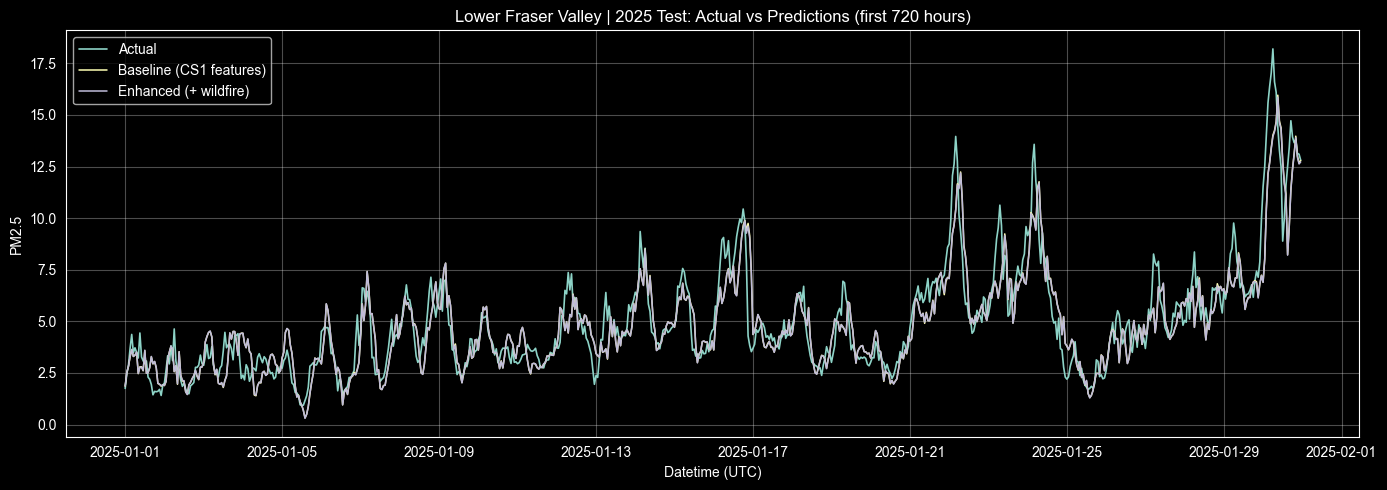

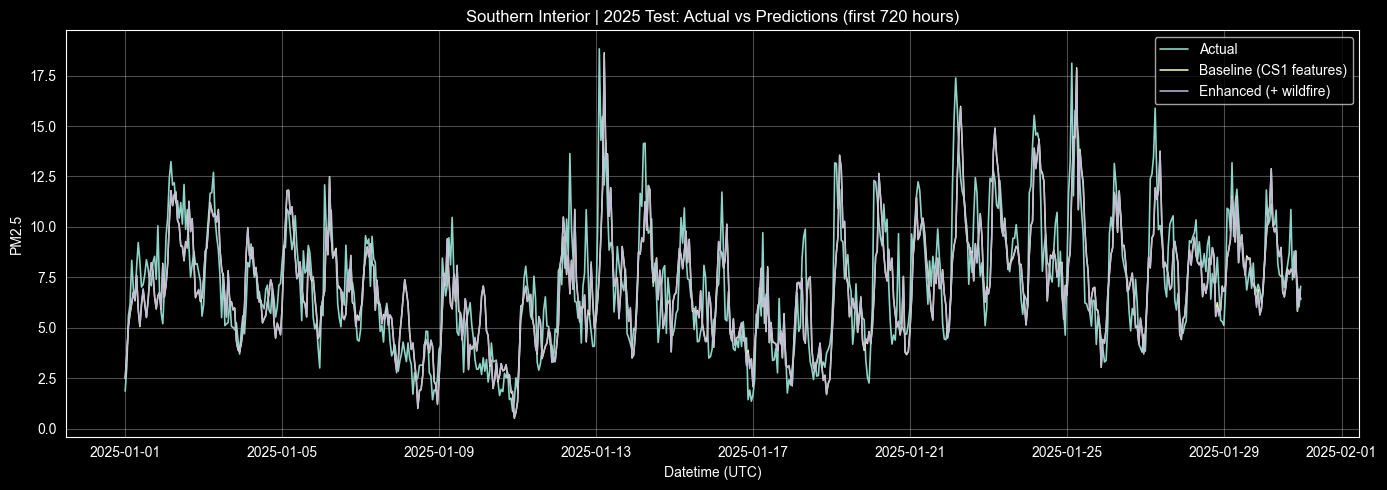

In [6]:
def plot_test_series(pred_base: pd.DataFrame, pred_enh: pd.DataFrame, zone: str, max_hours=24*21):
    # merge on datetime (inner join so both have same timestamps)
    a = pred_base.rename(columns={"y_pred": "y_pred_baseline"})[["Datetime_UTC", "y_true", "y_pred_baseline"]]
    b = pred_enh.rename(columns={"y_pred": "y_pred_enhanced"})[["Datetime_UTC", "y_pred_enhanced"]]
    m = a.merge(b, on="Datetime_UTC", how="inner").sort_values("Datetime_UTC")

    # optionally plot only first window for readability
    if max_hours is not None and len(m) > max_hours:
        m = m.iloc[:max_hours]

    plt.figure(figsize=(14, 5))
    plt.plot(m["Datetime_UTC"], m["y_true"], label="Actual", linewidth=1.2)
    plt.plot(m["Datetime_UTC"], m["y_pred_baseline"], label="Baseline (CS1 features)", linewidth=1.1)
    plt.plot(m["Datetime_UTC"], m["y_pred_enhanced"], label="Enhanced (+ wildfire)", linewidth=1.1)
    plt.title(f"{zone} | 2025 Test: Actual vs Predictions (first {len(m)} hours)")
    plt.xlabel("Datetime (UTC)")
    plt.ylabel("PM2.5")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

for z in zones:
    plot_test_series(preds_by_zone[z]["baseline"], preds_by_zone[z]["enhanced"], zone=z, max_hours=24*30)

In [7]:
# check wildfire season
THRESHOLD = 25.0

def filter_test_wildfire_season(d_model: pd.DataFrame, test_year=2025):
    d2 = d_model.copy()
    d2["year"] = d2["Datetime_UTC"].dt.year
    test = d2[d2["year"].eq(test_year)].copy()
    test_ws = test[test["is_wildfire_season"].eq(1)].copy()
    return test_ws

def eval_on_subset(gam, test_df: pd.DataFrame, feature_cols: list[str], threshold=25.0):
    X = test_df[feature_cols].values
    y = test_df["PM25"].values
    yhat = gam.predict(X)

    rmse = float(np.sqrt(mean_squared_error(y, yhat)))
    mae  = float(mean_absolute_error(y, yhat))
    r2   = float(r2_score(y, yhat))

    y_true_bin = (y > threshold).astype(int)
    y_pred_bin = (yhat > threshold).astype(int)

    prec = float(precision_score(y_true_bin, y_pred_bin, zero_division=0))
    rec  = float(recall_score(y_true_bin, y_pred_bin, zero_division=0))
    f1   = float(f1_score(y_true_bin, y_pred_bin, zero_division=0))

    return {
        "N_test_wildfire_season": int(len(test_df)),
        "RMSE_WS": rmse,
        "MAE_WS": mae,
        "R2_WS": r2,
        f"Precision@{threshold:g}_WS": prec,
        f"Recall@{threshold:g}_WS": rec,
        f"F1@{threshold:g}_WS": f1,
        "ActualEvents_WS": int(y_true_bin.sum()),
        "PredEvents_WS": int(y_pred_bin.sum()),
    }, pd.DataFrame({"Datetime_UTC": test_df["Datetime_UTC"].values,
                    "y_true": y,
                    "y_pred": yhat}).sort_values("Datetime_UTC")
zones = sorted(df["Zone"].unique())

all_rows_ws = []
preds_ws_by_zone = {}
models_by_zone = {}

for z in zones:
    dz = make_zone_table(df[df["Zone"] == z])

    # Fit on full 2022-2024 train (same as before)
    gam_base, m_base, p_base = fit_gam_and_eval(dz, BASE_COLS, threshold=THRESHOLD)
    gam_enh,  m_enh,  p_enh  = fit_gam_and_eval(dz, ENHANCED_COLS, threshold=THRESHOLD)

    models_by_zone[z] = {"baseline": gam_base, "enhanced": gam_enh}

    # Build the same modeling table used in training (dropna happens inside eval)
    d_model_base = dz.dropna(subset=BASE_COLS + ["PM25"]).copy()
    d_model_enh  = dz.dropna(subset=ENHANCED_COLS + ["PM25"]).copy()

    # Filter to 2025 wildfire season
    test_ws_base = filter_test_wildfire_season(d_model_base, test_year=2025)
    test_ws_enh  = filter_test_wildfire_season(d_model_enh,  test_year=2025)

    # Evaluate both models on wildfire season subset
    met_ws_base, pred_ws_base = eval_on_subset(gam_base, test_ws_base, BASE_COLS, threshold=THRESHOLD)
    met_ws_enh,  pred_ws_enh  = eval_on_subset(gam_enh,  test_ws_enh,  ENHANCED_COLS, threshold=THRESHOLD)

    all_rows_ws.append({"Zone": z, "Model": "Baseline_CS1Features_GAM", **met_ws_base})
    all_rows_ws.append({"Zone": z, "Model": "Enhanced_Wildfire_GAM", **met_ws_enh})

    preds_ws_by_zone[z] = {"baseline": pred_ws_base, "enhanced": pred_ws_enh}

metrics_ws_df = pd.DataFrame(all_rows_ws).sort_values(["Zone", "Model"]).reset_index(drop=True)
display(metrics_ws_df)


,Zone,Model,N_test_wildfire_season,RMSE_WS,MAE_WS,R2_WS,Precision@25_WS,Recall@25_WS,F1@25_WS,ActualEvents_WS,PredEvents_WS
0,Lower Fraser Valley,Baseline_CS1Features_GAM,4416,1.409304,0.745549,0.821102,0.500000,0.538462,0.518519,13,14
1,Lower Fraser Valley,Enhanced_Wildfire_GAM,4416,1.414979,0.755228,0.819659,0.500000,0.538462,0.518519,13,14
2,Southern Interior,Baseline_CS1Features_GAM,4416,1.800604,1.172958,0.910514,0.945455,0.896552,0.920354,116,110
3,Southern Interior,Enhanced_Wildfire_GAM,4416,1.833590,1.203466,0.907205,0.937500,0.905172,0.921053,116,112


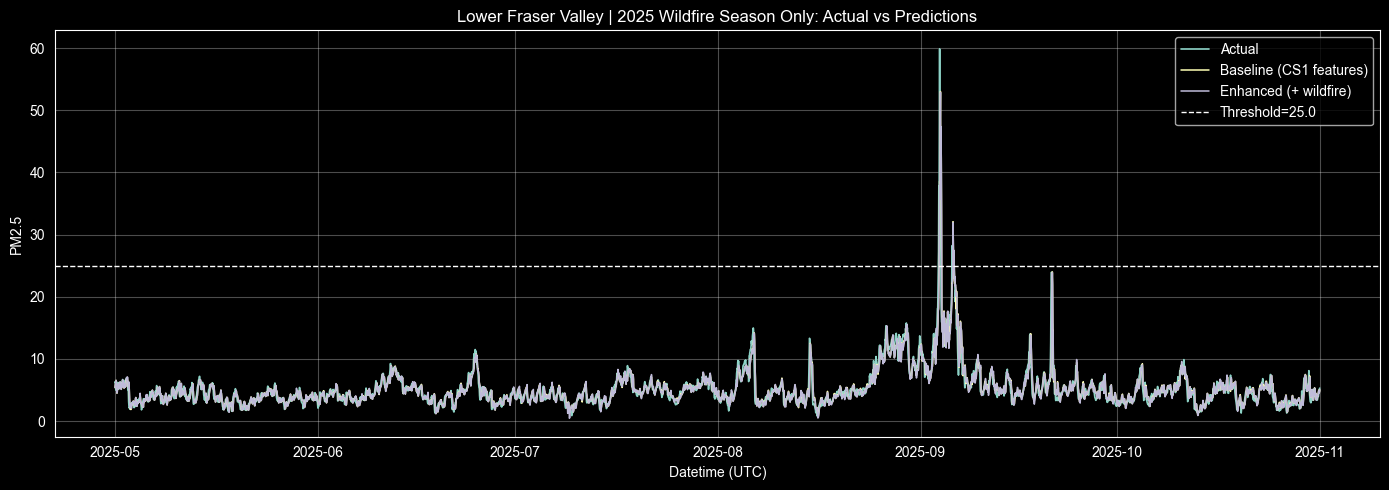

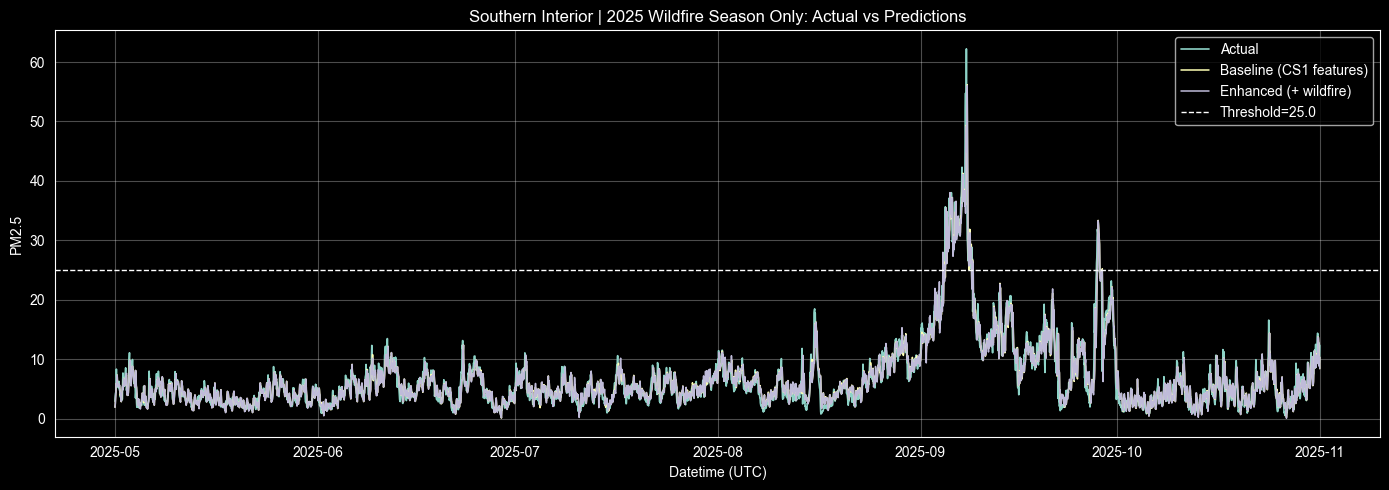

In [8]:
def plot_wildfire_season_series(pred_base: pd.DataFrame, pred_enh: pd.DataFrame, zone: str, threshold=25.0):
    a = pred_base.rename(columns={"y_pred": "y_pred_baseline"})[["Datetime_UTC", "y_true", "y_pred_baseline"]]
    b = pred_enh.rename(columns={"y_pred": "y_pred_enhanced"})[["Datetime_UTC", "y_pred_enhanced"]]
    m = a.merge(b, on="Datetime_UTC", how="inner").sort_values("Datetime_UTC")

    plt.figure(figsize=(14, 5))
    plt.plot(m["Datetime_UTC"], m["y_true"], label="Actual", linewidth=1.2)
    plt.plot(m["Datetime_UTC"], m["y_pred_baseline"], label="Baseline (CS1 features)", linewidth=1.1)
    plt.plot(m["Datetime_UTC"], m["y_pred_enhanced"], label="Enhanced (+ wildfire)", linewidth=1.1)
    plt.axhline(threshold, linestyle="--", linewidth=1, label=f"Threshold={threshold}")
    plt.title(f"{zone} | 2025 Wildfire Season Only: Actual vs Predictions")
    plt.xlabel("Datetime (UTC)")
    plt.ylabel("PM2.5")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

for z in zones:
    plot_wildfire_season_series(
        preds_ws_by_zone[z]["baseline"],
        preds_ws_by_zone[z]["enhanced"],
        zone=z,
        threshold=THRESHOLD
    )

## A simple try for transformer (pytorch)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

csv_path = Path("..") / "Dataset" / "Outputs" / "CS2_model_input.csv"  # notebook in /Model
df = pd.read_csv(csv_path)

df["Datetime_UTC"] = pd.to_datetime(df["Datetime_UTC"], utc=True, errors="coerce")
df = df.dropna(subset=["Datetime_UTC"]).sort_values(["Zone", "Datetime_UTC"]).reset_index(drop=True)

# Ensure numeric where needed
df["PM25"] = pd.to_numeric(df["PM25"], errors="coerce")

WILDFIRE_COLS = [
    "fire_count_regional", "frp_regional_sum", "hfi_weighted", "fwi_mean",
    "fire_count_local", "frp_local_sum",
]

BASE_COLS = [
    "PM25_lag_1h", "PM25_lag_6h", "PM25_lag_24h", "PM25_lag_48h",
    "PM25_roll_24h_mean", "PM25_roll_24h_max", "PM25_roll_7d_mean",
    "frp_roll_24h_sum", "frp_roll_72h_sum",
    "hour", "day_of_week", "month", "is_wildfire_season",
]

FEATURES = BASE_COLS + WILDFIRE_COLS
TARGET = "PM25"

Device: cuda
GPU: NVIDIA GeForce RTX 3070


In [14]:
SEQ_LEN = 48      # past 48 hours
HORIZON = 3       # predict 3 hours ahead

def build_zone_frame(df_zone: pd.DataFrame) -> pd.DataFrame:
    d = df_zone.copy().sort_values("Datetime_UTC")
    # coerce features to numeric
    for c in FEATURES:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d[TARGET] = pd.to_numeric(d[TARGET], errors="coerce")
    d = d.dropna(subset=FEATURES + [TARGET])
    d["year"] = d["Datetime_UTC"].dt.year
    return d

def make_sequences(X: np.ndarray, y: np.ndarray, seq_len: int, horizon: int):
    # X shape: (T, F), y shape: (T,)
    T = len(X)
    Xs, ys = [], []
    # last usable index t is T - horizon - 1
    for t in range(seq_len - 1, T - horizon):
        Xs.append(X[t - seq_len + 1 : t + 1])
        ys.append(y[t + horizon])
    return np.stack(Xs), np.array(ys)

In [15]:
class SeqDataset(Dataset):
    def __init__(self, X_seq, y):
        self.X = torch.tensor(X_seq, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

In [16]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        # x: (B, L, D)
        L = x.size(1)
        return x + self.pe[:, :L, :]

class TransformerRegressor(nn.Module):
    def __init__(self, n_features, d_model=64, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos = PositionalEncoding(d_model, max_len=512)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, 1),
        )

    def forward(self, x):
        # x: (B, L, F)
        h = self.input_proj(x)         # (B, L, D)
        h = self.pos(h)
        h = self.encoder(h)            # (B, L, D)
        h_last = h[:, -1, :]           # last timestep representation
        out = self.head(h_last).squeeze(-1)  # (B,)
        return out

In [17]:
def train_one_zone(dz: pd.DataFrame, zone_name: str, epochs=10, batch_size=256, lr=1e-3):
    # split
    train_df = dz[dz["year"].isin([2022, 2023, 2024])].copy()
    test_df  = dz[dz["year"].eq(2025)].copy()

    # scale using TRAIN only
    scaler = StandardScaler()
    X_train_raw = scaler.fit_transform(train_df[FEATURES].values)
    y_train_raw = train_df[TARGET].values

    X_test_raw = scaler.transform(test_df[FEATURES].values)
    y_test_raw = test_df[TARGET].values

    # sequences
    Xtr_seq, ytr = make_sequences(X_train_raw, y_train_raw, SEQ_LEN, HORIZON)
    Xte_seq, yte = make_sequences(X_test_raw,  y_test_raw,  SEQ_LEN, HORIZON)

    train_loader = DataLoader(SeqDataset(Xtr_seq, ytr), batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=(device.type=="cuda"))
    test_loader  = DataLoader(SeqDataset(Xte_seq, yte), batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=(device.type=="cuda"))

    model = TransformerRegressor(n_features=len(FEATURES), d_model=64, n_heads=4, n_layers=2, dropout=0.1).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    use_amp = (device.type == "cuda")
    scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)

    for ep in range(1, epochs+1):
        model.train()
        total = 0.0
        n = 0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                pred = model(xb)
                loss = loss_fn(pred, yb)

            scaler_amp.scale(loss).backward()
            scaler_amp.step(opt)
            scaler_amp.update()

            total += loss.item() * len(yb)
            n += len(yb)

        train_mse = total / max(n, 1)

        # quick eval
        model.eval()
        preds = []
        trues = []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(device, non_blocking=True)
                pred = model(xb).detach().cpu().numpy()
                preds.append(pred)
                trues.append(yb.numpy())

        yhat = np.concatenate(preds)
        ytrue = np.concatenate(trues)

        rmse = float(np.sqrt(mean_squared_error(ytrue, yhat)))
        mae  = float(mean_absolute_error(ytrue, yhat))
        r2   = float(r2_score(ytrue, yhat))

        print(f"[{zone_name}] epoch {ep:02d} | train_mse={train_mse:.4f} | test RMSE={rmse:.4f} MAE={mae:.4f} R2={r2:.4f}")

    # return final predictions aligned to test timestamps (for plotting)
    # rebuild timestamps for test sequences:
    test_times = test_df["Datetime_UTC"].values
    # sequence targets start at index (SEQ_LEN-1 + HORIZON)
    start_idx = (SEQ_LEN - 1 + HORIZON)
    pred_times = test_times[start_idx : start_idx + len(yhat)]

    pred_df = pd.DataFrame({"Datetime_UTC": pred_times, "y_true": ytrue, "y_pred": yhat}).sort_values("Datetime_UTC")
    metrics = {"Zone": zone_name, "RMSE": rmse, "MAE": mae, "R2": r2, "N_test": int(len(pred_df))}

    return model, scaler, metrics, pred_df

In [20]:
zones = sorted(df["Zone"].unique())
results = []
preds_by_zone = {}

for z in zones:
    dz = build_zone_frame(df[df["Zone"] == z])
    model, sc, met, pred_df = train_one_zone(dz, z, epochs=10, batch_size=256, lr=1e-3)
    results.append(met)
    preds_by_zone[z] = pred_df

pd.DataFrame(results)

D:\Model\Data-Science-Case-Study-1\.venv\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\user\AppData\Local\Temp\ipykernel_19484\3134475043.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)
C:\Users\user\AppData\Local\Temp\ipykernel_19484\3134475043.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[Lower Fraser Valley] epoch 01 | train_mse=21.6803 | test RMSE=1.5528 MAE=0.9066 R2=0.6914


C:\Users\user\AppData\Local\Temp\ipykernel_19484\3134475043.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[Lower Fraser Valley] epoch 02 | train_mse=8.6799 | test RMSE=1.4698 MAE=0.8361 R2=0.7235


C:\Users\user\AppData\Local\Temp\ipykernel_19484\3134475043.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


...

C:\Users\user\AppData\Local\Temp\ipykernel_19484\3134475043.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[Southern Interior] epoch 09 | train_mse=8.1649 | test RMSE=2.1202 MAE=1.3841 R2=0.8103


C:\Users\user\AppData\Local\Temp\ipykernel_19484\3134475043.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[Southern Interior] epoch 10 | train_mse=7.8425 | test RMSE=2.1083 MAE=1.3958 R2=0.8124


,Zone,RMSE,MAE,R2,N_test
0,Lower Fraser Valley,1.441560,0.843900,0.734058,8710
1,Southern Interior,2.108289,1.395801,0.812424,8710


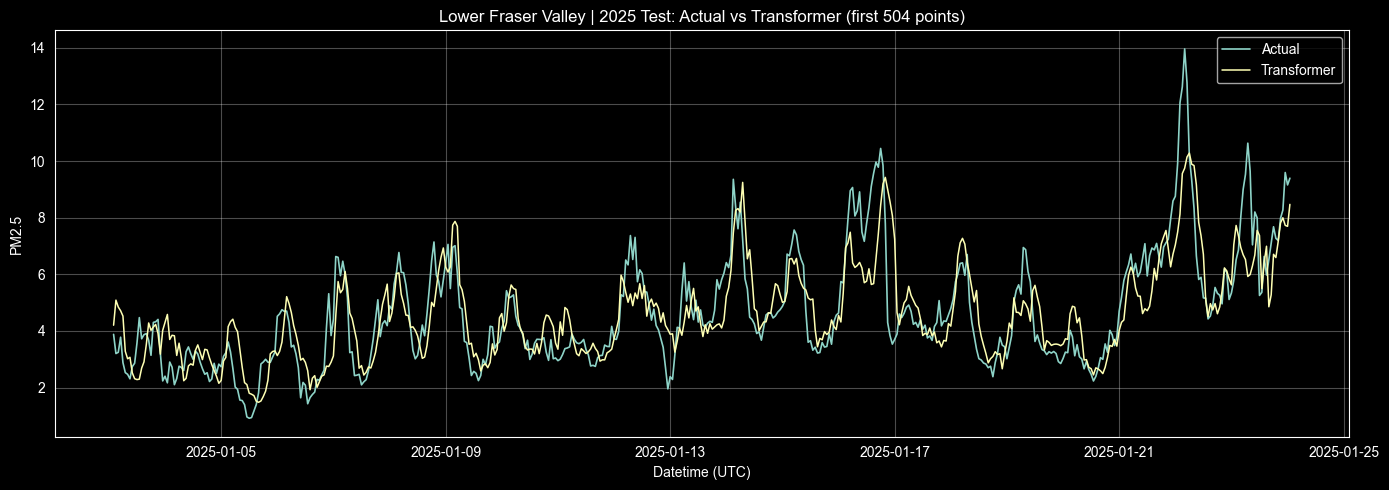

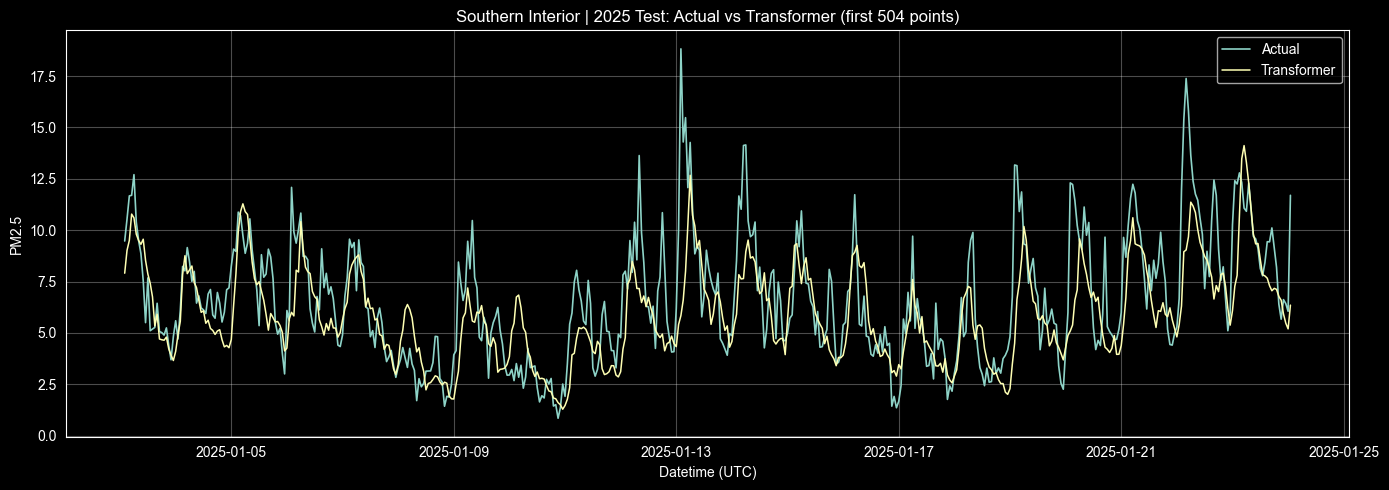

In [21]:
def plot_transformer(pred_df: pd.DataFrame, zone: str, max_hours=24*21):
    d = pred_df.sort_values("Datetime_UTC").copy()
    if max_hours is not None and len(d) > max_hours:
        d = d.iloc[:max_hours]

    plt.figure(figsize=(14, 5))
    plt.plot(d["Datetime_UTC"], d["y_true"], label="Actual", linewidth=1.2)
    plt.plot(d["Datetime_UTC"], d["y_pred"], label="Transformer", linewidth=1.1)
    plt.title(f"{zone} | 2025 Test: Actual vs Transformer (first {len(d)} points)")
    plt.xlabel("Datetime (UTC)")
    plt.ylabel("PM2.5")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

for z in zones:
    plot_transformer(preds_by_zone[z], z, max_hours=24*21)

## Raw-history Transformer(ignore added lag and do simple hyperparameter tuning)

In [22]:
THRESHOLD = 25.0

RAW_FEATURES = [
    "PM25",
    "fire_count_regional", "frp_regional_sum", "hfi_weighted", "fwi_mean",
    "fire_count_local", "frp_local_sum",
    "hour", "day_of_week", "month", "is_wildfire_season",
]
TARGET = "PM25"
csv_path = Path("..") / "Dataset" / "Outputs" / "CS2_model_input.csv"  # notebook in /Model
df = pd.read_csv(csv_path)

df["Datetime_UTC"] = pd.to_datetime(df["Datetime_UTC"], utc=True, errors="coerce")
df = df.dropna(subset=["Datetime_UTC"]).sort_values(["Zone", "Datetime_UTC"]).reset_index(drop=True)

def build_zone_frame_raw(df_zone: pd.DataFrame) -> pd.DataFrame:
    d = df_zone.copy().sort_values("Datetime_UTC")
    for c in RAW_FEATURES + [TARGET]:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d = d.dropna(subset=RAW_FEATURES + [TARGET])
    d["year"] = d["Datetime_UTC"].dt.year
    return d

class SeqDataset(Dataset):
    def __init__(self, X_seq, y, t, wildfire_flag=None):
        self.X = torch.tensor(X_seq, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.t = t
        self.ws = wildfire_flag  # numpy array aligned to y (optional)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i], i

def make_sequences_from_frame(d: pd.DataFrame, features, target, seq_len, horizon):
    X = d[features].values  # (T,F)
    y = d[target].values
    t = d["Datetime_UTC"].values
    ws = d["is_wildfire_season"].values.astype(int)

    Xs, ys, ts, wss = [], [], [], []
    for idx in range(seq_len - 1, len(d) - horizon):
        Xs.append(X[idx - seq_len + 1: idx + 1])
        ys.append(y[idx + horizon])
        ts.append(t[idx + horizon])
        wss.append(ws[idx + horizon])

    return np.stack(Xs), np.array(ys), np.array(ts), np.array(wss)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1024):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))  # [1, max_len, d_model]

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TransformerRegressor(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4, num_layers=2, dim_ff=256, dropout=0.1):
        super().__init__()
        self.in_proj = nn.Linear(n_features, d_model)
        self.pos = PositionalEncoding(d_model)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation="gelu", norm_first=True
        )
        self.enc = nn.TransformerEncoder(layer, num_layers=num_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: [B, T, F]
        h = self.in_proj(x)
        h = self.pos(h)
        h = self.enc(h)
        h_last = h[:, -1, :]
        return self.head(h_last).squeeze(-1)

In [23]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1024):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))  # [1, max_len, d_model]

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TransformerRegressor(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4, num_layers=2, dim_ff=256, dropout=0.1):
        super().__init__()
        self.in_proj = nn.Linear(n_features, d_model)
        self.pos = PositionalEncoding(d_model)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation="gelu", norm_first=True
        )
        self.enc = nn.TransformerEncoder(layer, num_layers=num_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: [B, T, F]
        h = self.in_proj(x)
        h = self.pos(h)
        h = self.enc(h)
        h_last = h[:, -1, :]
        return self.head(h_last).squeeze(-1)

In [28]:
def compute_metrics(y_true, y_pred, threshold=25.0):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))

    ytb = (y_true > threshold).astype(int)
    ypb = (y_pred > threshold).astype(int)
    prec = float(precision_score(ytb, ypb, zero_division=0))
    rec = float(recall_score(ytb, ypb, zero_division=0))
    f1v = float(f1_score(ytb, ypb, zero_division=0))
    return {"RMSE": rmse, "MAE": mae, "R2": r2,
            f"Precision@{threshold:g}": prec, f"Recall@{threshold:g}": rec, f"F1@{threshold:g}": f1v,
            "ActualEvents": int(ytb.sum()), "PredEvents": int(ypb.sum())}

def train_transformer_zone_raw(
    dz: pd.DataFrame,
    zone_name: str,
    seq_len=72,
    horizon=3,
    d_model=64,
    n_layers=2,
    nhead=4,
    batch_size=256,
    lr=1e-3,
    max_epochs=30,
    patience=5,
):
    # split
    train_df = dz[dz["year"].isin([2022, 2023, 2024])].copy()
    test_df  = dz[dz["year"].eq(2025)].copy()

    # ---- scale features using TRAIN only (do NOT write back to df) ----
    scaler = StandardScaler()

    X_train_raw = scaler.fit_transform(train_df[RAW_FEATURES].astype(float).values)
    y_train_raw = train_df[TARGET].astype(float).values
    ws_train = train_df["is_wildfire_season"].astype(int).values
    t_train = train_df["Datetime_UTC"].values

    X_test_raw = scaler.transform(test_df[RAW_FEATURES].astype(float).values)
    y_test_raw = test_df[TARGET].astype(float).values
    ws_test = test_df["is_wildfire_season"].astype(int).values
    t_test = test_df["Datetime_UTC"].values

    def make_sequences_from_arrays(X, y, t, ws, seq_len, horizon):
        Xs, ys, ts, wss = [], [], [], []
        for idx in range(seq_len - 1, len(y) - horizon):
            Xs.append(X[idx - seq_len + 1: idx + 1])
            ys.append(y[idx + horizon])
            ts.append(t[idx + horizon])
            wss.append(ws[idx + horizon])
        return np.stack(Xs), np.array(ys), np.array(ts), np.array(wss)

    Xtr, ytr, ttr, wtr = make_sequences_from_arrays(X_train_raw, y_train_raw, t_train, ws_train, seq_len, horizon)
    Xte, yte, tte, wte = make_sequences_from_arrays(X_test_raw,  y_test_raw,  t_test,  ws_test,  seq_len, horizon)

    # train/val split (last 10% as val to preserve time order)
    n = len(ytr)
    n_val = max(1, int(0.1 * n))
    split = n - n_val
    X_train, y_train = Xtr[:split], ytr[:split]
    X_val, y_val     = Xtr[split:], ytr[split:]

    train_loader = DataLoader(SeqDataset(X_train, y_train, None), batch_size=batch_size, shuffle=True,
                              pin_memory=(device.type=="cuda"))
    val_loader   = DataLoader(SeqDataset(X_val, y_val, None), batch_size=batch_size, shuffle=False,
                              pin_memory=(device.type=="cuda"))
    test_loader  = DataLoader(SeqDataset(Xte, yte, tte, wildfire_flag=wte), batch_size=batch_size, shuffle=False,
                              pin_memory=(device.type=="cuda"))

    model = TransformerRegressor(len(RAW_FEATURES), d_model=d_model, nhead=nhead, num_layers=n_layers, dim_ff=4*d_model).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.SmoothL1Loss()  # ✅ Huber
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=2)

    best_val = float("inf")
    best_state = None
    bad = 0

    use_amp = (device.type == "cuda")
    scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)

    for ep in range(1, max_epochs + 1):
        model.train()
        tr_losses = []
        for xb, yb, _ in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                pred = model(xb)
                loss = loss_fn(pred, yb)

            scaler_amp.scale(loss).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler_amp.step(opt)
            scaler_amp.update()
            tr_losses.append(loss.item())

        # val
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb, _ in val_loader:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                pred = model(xb)
                val_losses.append(loss_fn(pred, yb).item())

        val_loss = float(np.mean(val_losses))
        sched.step(val_loss)

        print(f"[{zone_name}] ep {ep:02d} | train_loss {np.mean(tr_losses):.4f} | val_loss {val_loss:.4f} | lr {opt.param_groups[0]['lr']:.2e}")

        if val_loss < best_val - 1e-4:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"[{zone_name}] Early stopping at epoch {ep}")
                break

    model.load_state_dict(best_state)

    # test preds
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, yb, _ in test_loader:
            xb = xb.to(device, non_blocking=True)
            preds.append(model(xb).detach().cpu().numpy())
    yhat = np.concatenate(preds)

    # overall metrics
    met_all = compute_metrics(yte, yhat, threshold=THRESHOLD)

    # wildfire season metrics
    mask_ws = (wte == 1)
    if mask_ws.sum() > 0:
        met_ws = compute_metrics(yte[mask_ws], yhat[mask_ws], threshold=THRESHOLD)
    else:
        met_ws = {"RMSE": np.nan, "MAE": np.nan, "R2": np.nan,
                  f"Precision@{THRESHOLD:g}": np.nan, f"Recall@{THRESHOLD:g}": np.nan, f"F1@{THRESHOLD:g}": np.nan,
                  "ActualEvents": 0, "PredEvents": 0}

    pred_df = pd.DataFrame({"Datetime_UTC": tte, "y_true": yte, "y_pred": yhat, "is_wildfire_season": wte}).sort_values("Datetime_UTC")

    return model, {"Zone": zone_name, "SEQ_LEN": seq_len, "HORIZON": horizon, **met_all}, {"Zone": zone_name, "SEQ_LEN": seq_len, "HORIZON": horizon, **{k+"_WS": v for k,v in met_ws.items()}}, pred_df

In [29]:
zones = sorted(df["Zone"].unique())
grid_seq = [72, 168]
grid_h = [1, 3]

all_all = []
all_ws = []
preds_best = {}

for z in zones:
    dz = build_zone_frame_raw(df[df["Zone"] == z])

    best_rmse = float("inf")
    best_pack = None

    for seq_len in grid_seq:
        for horizon in grid_h:
            print("\n", "="*80)
            print(f"ZONE={z} | SEQ_LEN={seq_len} | HORIZON={horizon}")
            model, met_all, met_ws, pred_df = train_transformer_zone_raw(
                dz, z, seq_len=seq_len, horizon=horizon,
                d_model=64, n_layers=2, nhead=4,
                batch_size=256, lr=1e-3, max_epochs=30, patience=5
            )

            all_all.append(met_all)
            all_ws.append(met_ws)

            if met_all["RMSE"] < best_rmse:
                best_rmse = met_all["RMSE"]
                best_pack = (seq_len, horizon, pred_df)

    preds_best[z] = {"seq_len": best_pack[0], "horizon": best_pack[1], "pred_df": best_pack[2]}

all_df = pd.DataFrame(all_all).sort_values(["Zone","RMSE"]).reset_index(drop=True)
ws_df = pd.DataFrame(all_ws).sort_values(["Zone","RMSE_WS"]).reset_index(drop=True)

display(all_df)
display(ws_df)


ZONE=Lower Fraser Valley | SEQ_LEN=72 | HORIZON=1


D:\Model\Data-Science-Case-Study-1\.venv\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\user\AppData\Local\Temp\ipykernel_19484\3270658057.py:81: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)
C:\Users\user\AppData\Local\Temp\ipykernel_19484\3270658057.py:91: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[Lower Fraser Valley] ep 01 | train_loss 1.4408 | val_loss 0.2025 | lr 1.00e-03
[Lower Fraser Valley] ep 02 | train_loss 0.4799 | val_loss 0.3202 | lr 1.00e-03
[Lower Fraser Valley] ep 03 | train_loss 0.3825 | val_loss 0.1748 | lr 1.00e-03
[Lower Fraser Valley] ep 04 | train_loss 0.3523 | val_loss 0.1816 | lr 1.00e-03
[Lower Fraser Valley] ep 05 | train_loss 0.3548 | val_loss 0.1596 | lr 1.00e-03
[Lower Fraser Valley] ep 06 | train_loss 0.3313 | val_loss 0.2074 | lr 1.00e-03
[Lower Fraser Valley] ep 07 | train_loss 0.3148 | val_loss 0.1604 | lr 1.00e-03
[Lower Fraser Valley] ep 08 | train_loss 0.2941 | val_loss 0.1557 | lr 1.00e-03
[Lower Fraser Valley] ep 09 | train_loss 0.2944 | val_loss 0.2175 | lr 1.00e-03
[Lower Fraser Valley] ep 10 | train_loss 0.2765 | val_loss 0.1506 | lr 1.00e-03
[Lower Fraser Valley] ep 11 | train_loss 0.2682 | val_loss 0.1656 | lr 1.00e-03
[Lower Fraser Valley] ep 12 | train_loss 0.2605 | val_loss 0.1520 | lr 1.00e-03
[Lower Fraser Valley] ep 13 | train_loss

D:\Model\Data-Science-Case-Study-1\.venv\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\user\AppData\Local\Temp\ipykernel_19484\3270658057.py:81: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)
C:\Users\user\AppData\Local\Temp\ipykernel_19484\3270658057.py:91: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[Lower Fraser Valley] ep 01 | train_loss 1.5976 | val_loss 0.5312 | lr 1.00e-03
[Lower Fraser Valley] ep 02 | train_loss 0.7979 | val_loss 0.4691 | lr 1.00e-03
[Lower Fraser Valley] ep 03 | train_loss 0.7065 | val_loss 0.4955 | lr 1.00e-03
[Lower Fraser Valley] ep 04 | train_loss 0.6851 | val_loss 0.4339 | lr 1.00e-03
[Lower Fraser Valley] ep 05 | train_loss 0.6317 | val_loss 0.4274 | lr 1.00e-03
[Lower Fraser Valley] ep 06 | train_loss 0.6175 | val_loss 0.4290 | lr 1.00e-03
[Lower Fraser Valley] ep 07 | train_loss 0.6071 | val_loss 0.4359 | lr 1.00e-03
[Lower Fraser Valley] ep 08 | train_loss 0.5935 | val_loss 0.4598 | lr 5.00e-04
[Lower Fraser Valley] ep 09 | train_loss 0.5811 | val_loss 0.4286 | lr 5.00e-04
[Lower Fraser Valley] ep 10 | train_loss 0.5748 | val_loss 0.4177 | lr 5.00e-04
[Lower Fraser Valley] ep 11 | train_loss 0.5662 | val_loss 0.4107 | lr 5.00e-04
[Lower Fraser Valley] ep 12 | train_loss 0.5511 | val_loss 0.4127 | lr 5.00e-04
[Lower Fraser Valley] ep 13 | train_loss

...

[Southern Interior] ep 01 | train_loss 3.0992 | val_loss 0.6753 | lr 1.00e-03
[Southern Interior] ep 02 | train_loss 1.4002 | val_loss 0.7164 | lr 1.00e-03
[Southern Interior] ep 03 | train_loss 1.1070 | val_loss 0.5699 | lr 1.00e-03
[Southern Interior] ep 04 | train_loss 1.0052 | val_loss 0.6563 | lr 1.00e-03
[Southern Interior] ep 05 | train_loss 0.9113 | val_loss 0.5950 | lr 1.00e-03
[Southern Interior] ep 06 | train_loss 0.8689 | val_loss 0.5342 | lr 1.00e-03
[Southern Interior] ep 07 | train_loss 0.7950 | val_loss 0.5413 | lr 1.00e-03
[Southern Interior] ep 08 | train_loss 0.7457 | val_loss 0.5410 | lr 1.00e-03
[Southern Interior] ep 09 | train_loss 0.7330 | val_loss 0.5385 | lr 5.00e-04
[Southern Interior] ep 10 | train_loss 0.6612 | val_loss 0.5602 | lr 5.00e-04
[Southern Interior] ep 11 | train_loss 0.6573 | val_loss 0.5300 | lr 5.00e-04
[Southern Interior] ep 12 | train_loss 0.6546 | val_loss 0.5369 | lr 5.00e-04
[Southern Interior] ep 13 | train_loss 0.6479 | val_loss 0.6379 

D:\Model\Data-Science-Case-Study-1\.venv\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
C:\Users\user\AppData\Local\Temp\ipykernel_19484\3270658057.py:81: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)
C:\Users\user\AppData\Local\Temp\ipykernel_19484\3270658057.py:91: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[Southern Interior] ep 01 | train_loss 3.2506 | val_loss 0.9730 | lr 1.00e-03
[Southern Interior] ep 02 | train_loss 1.7237 | val_loss 0.8995 | lr 1.00e-03
[Southern Interior] ep 03 | train_loss 1.5228 | val_loss 0.8835 | lr 1.00e-03
[Southern Interior] ep 04 | train_loss 1.4263 | val_loss 0.8631 | lr 1.00e-03
[Southern Interior] ep 05 | train_loss 1.3441 | val_loss 1.1438 | lr 1.00e-03
[Southern Interior] ep 06 | train_loss 1.2914 | val_loss 0.8071 | lr 1.00e-03
[Southern Interior] ep 07 | train_loss 1.2284 | val_loss 0.8941 | lr 1.00e-03
[Southern Interior] ep 08 | train_loss 1.1792 | val_loss 0.8118 | lr 1.00e-03
[Southern Interior] ep 09 | train_loss 1.1322 | val_loss 0.8175 | lr 5.00e-04
[Southern Interior] ep 10 | train_loss 1.0762 | val_loss 0.8299 | lr 5.00e-04
[Southern Interior] ep 11 | train_loss 1.0626 | val_loss 0.8589 | lr 5.00e-04
[Southern Interior] Early stopping at epoch 11


,Zone,SEQ_LEN,HORIZON,RMSE,MAE,R2,Precision@25,Recall@25,F1@25,ActualEvents,PredEvents
0,Lower Fraser Valley,72,1,0.604130,0.330941,0.953384,0.714286,0.769231,0.740741,13,14
1,Lower Fraser Valley,168,1,0.662924,0.351068,0.944194,0.733333,0.846154,0.785714,13,15
2,Lower Fraser Valley,72,3,1.176172,0.684314,0.823324,0.600000,0.461538,0.521739,13,10
3,Lower Fraser Valley,168,3,1.184006,0.689101,0.822025,0.466667,0.538462,0.500000,13,15
4,Southern Interior,168,1,1.192465,0.786398,0.940619,0.972973,0.931034,0.951542,116,111
5,Southern Interior,72,1,1.202716,0.791712,0.939053,0.972477,0.913793,0.942222,116,109
6,Southern Interior,72,3,1.840073,1.216029,0.857373,0.942308,0.844828,0.890909,116,104
7,Southern Interior,168,3,1.971431,1.307749,0.837727,0.930435,0.922414,0.926407,116,115


,Zone,SEQ_LEN,HORIZON,RMSE_WS,MAE_WS,R2_WS,Precision@25_WS,Recall@25_WS,F1@25_WS,ActualEvents_WS,PredEvents_WS
0,Lower Fraser Valley,72,1,0.711994,0.332033,0.954339,0.714286,0.769231,0.740741,13,14
1,Lower Fraser Valley,168,1,0.798880,0.359165,0.942514,0.733333,0.846154,0.785714,13,15
2,Lower Fraser Valley,72,3,1.406026,0.732552,0.821934,0.600000,0.461538,0.521739,13,10
3,Lower Fraser Valley,168,3,1.409143,0.726263,0.821143,0.466667,0.538462,0.500000,13,15
4,Southern Interior,168,1,1.108323,0.686489,0.966096,0.972973,0.931034,0.951542,116,111
5,Southern Interior,72,1,1.120495,0.689031,0.965347,0.972477,0.913793,0.942222,116,109
6,Southern Interior,72,3,1.874474,1.148418,0.903021,0.942308,0.844828,0.890909,116,104
7,Southern Interior,168,3,2.007382,1.233901,0.888781,0.930435,0.922414,0.926407,116,115


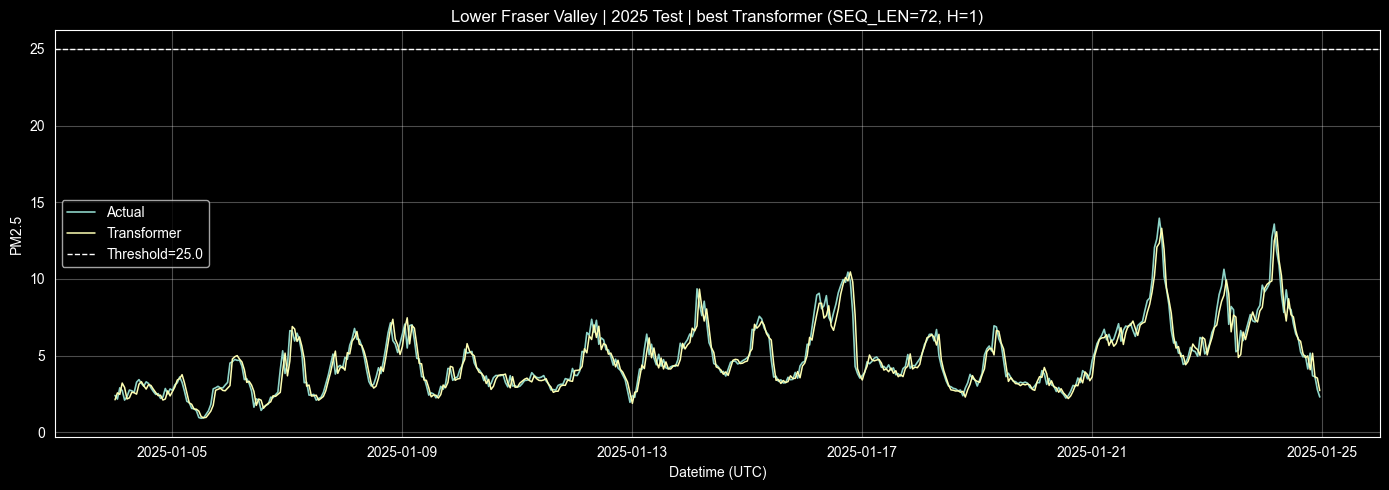

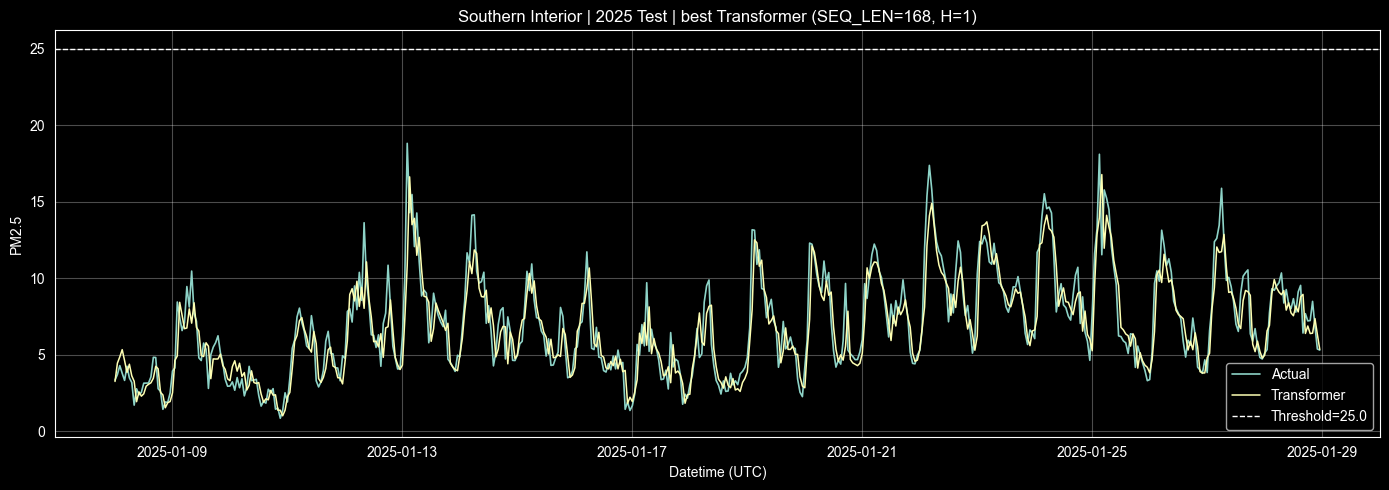

In [30]:
def plot_pred(pred_df, zone, horizon, seq_len, max_hours=24*21):
    d = pred_df.sort_values("Datetime_UTC").copy()
    if max_hours is not None and len(d) > max_hours:
        d = d.iloc[:max_hours]

    plt.figure(figsize=(14, 5))
    plt.plot(d["Datetime_UTC"], d["y_true"], label="Actual", linewidth=1.2)
    plt.plot(d["Datetime_UTC"], d["y_pred"], label="Transformer", linewidth=1.1)
    plt.axhline(THRESHOLD, linestyle="--", linewidth=1, label=f"Threshold={THRESHOLD}")
    plt.title(f"{zone} | 2025 Test | best Transformer (SEQ_LEN={seq_len}, H={horizon})")
    plt.xlabel("Datetime (UTC)")
    plt.ylabel("PM2.5")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

for z in zones:
    pack = preds_best[z]
    plot_pred(pack["pred_df"], z, horizon=pack["horizon"], seq_len=pack["seq_len"], max_hours=24*21)